In [30]:
import numpy as np
import psutil
import subprocess
import random as rd
import pickle
import gc
from qiskit.quantum_info import SparsePauliOp
from qiskit_nature.second_q.mappers import LogarithmicMapper

def memory_usage(message: str = 'debug'):
    # this memory_usage function is imported from https://jybaek.tistory.com/895
    # current process RAM usage
    p = psutil.Process()
    rss = p.memory_info().rss / 2 ** 30 # Bytes to GiB
    print(f"[{message}] memory usage: {rss: 10.5f} GiB")


def single_line (lines):
    return ''.join(lines.splitlines())

In [31]:
n_x = 4
n_y = 1
n_site = n_x * n_y
n_qubit = n_site
dim = 2**n_qubit

n_qubit_circuit = n_qubit + 1

n_dimer = n_site//2

core  = 0
cores = 1

In [32]:
seed_transpiler = 42

In [33]:
from qiskit import QuantumRegister, QuantumCircuit
qr_circuit = QuantumRegister(n_qubit_circuit,name='q')
#qr = qr_circuit[1:]
#qm = qr_circuit[0]
#indx_qm = 0
indx_qm = 2
qm = qr_circuit[indx_qm]
qr = qr_circuit[:indx_qm] + qr_circuit[indx_qm+1:]
#print(qm,qr)

In [34]:
J                   = 1.0
Delta               = -1.0
h                   = 0.0

In [35]:
n_inter             = 2
t_inter_max         = 1.0
t_inters            = [0.0, 1.0]
hamiltonians        = []
mapper = LogarithmicMapper()
for i_inter in range(n_inter):
    t_inter = t_inters[i_inter]
    hamiltonian_list = []
    # intra-dimer terms
    for i in range(0,n_qubit,2):
        ii = i
        #jj = (i+1)%n_qubit # periodic boundary condition
        jj = (i+1) # open boundary condition
        if (jj>=n_qubit):
            continue
        term = ('XX',[ii,jj],-J/4)
        hamiltonian_list.append(term)
        term = ('YY',[ii,jj],-J/4)
        hamiltonian_list.append(term)
        term = ('ZZ',[ii,jj],-J*Delta/4)
        hamiltonian_list.append(term)
        term = ('Z',[ii],-h/2)
        hamiltonian_list.append(term)
        term = ('Z',[jj],-h/2)
        hamiltonian_list.append(term)
    # inter-dimer terms
    for i in range(1,n_qubit,2):
        ii = i
        #jj = (i+1)%n_qubit # periodic boundary condition
        jj = (i+1) # open boundary condition
        if (jj>=n_qubit):
            continue
        term = ('XX',[ii,jj],-J*t_inter/4)
        hamiltonian_list.append(term)
        term = ('YY',[ii,jj],-J*t_inter/4)
        hamiltonian_list.append(term)
        term = ('ZZ',[ii,jj],-J*t_inter*Delta/4)
        hamiltonian_list.append(term)
    print(hamiltonian_list)
    hamiltonian = SparsePauliOp.from_sparse_list(hamiltonian_list,num_qubits=n_qubit)
    hamiltonians.append(hamiltonian.simplify())

    if (core==0):
        print(t_inter, single_line(str(hamiltonians[i_inter])))
        print('')

[('XX', [0, 1], -0.25), ('YY', [0, 1], -0.25), ('ZZ', [0, 1], 0.25), ('Z', [0], -0.0), ('Z', [1], -0.0), ('XX', [2, 3], -0.25), ('YY', [2, 3], -0.25), ('ZZ', [2, 3], 0.25), ('Z', [2], -0.0), ('Z', [3], -0.0), ('XX', [1, 2], -0.0), ('YY', [1, 2], -0.0), ('ZZ', [1, 2], 0.0)]
0.0 SparsePauliOp(['IIXX', 'IIYY', 'IIZZ', 'XXII', 'YYII', 'ZZII'],              coeffs=[-0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j])

[('XX', [0, 1], -0.25), ('YY', [0, 1], -0.25), ('ZZ', [0, 1], 0.25), ('Z', [0], -0.0), ('Z', [1], -0.0), ('XX', [2, 3], -0.25), ('YY', [2, 3], -0.25), ('ZZ', [2, 3], 0.25), ('Z', [2], -0.0), ('Z', [3], -0.0), ('XX', [1, 2], -0.25), ('YY', [1, 2], -0.25), ('ZZ', [1, 2], 0.25)]
1.0 SparsePauliOp(['IIXX', 'IIYY', 'IIZZ', 'XXII', 'YYII', 'ZZII', 'IXXI', 'IYYI', 'IZZI'],              coeffs=[-0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j])



In [36]:
init_circuit = QuantumCircuit(qr_circuit)
# qm is at the middle of 1 and 2 for 4 site
n_dimer_half = n_dimer//2
index_attached_to_qm = n_qubit//2-1

#  geometry ; qm -- qr[n_qubit//2-1] -- ... -- qr[1] -- qr[0]
#                   \--qr[n_qubit//2] -- ... -- qr[n_qubit-1]
init_circuit.cx(qm,qr[index_attached_to_qm])

init_circuit.cx(qr[index_attached_to_qm],qr[index_attached_to_qm+1])
for i_dimer in range(1,n_dimer_half+1):
    i_qubit = 2*(i_dimer+n_dimer_half-1)
    init_circuit.s(qr[i_qubit+1])
    init_circuit.h(qr[i_qubit+1])
    init_circuit.t(qr[i_qubit+1])
    init_circuit.cx(qr[i_qubit],qr[i_qubit+1])
    init_circuit.tdg(qr[i_qubit+1])
    if (i_dimer<n_dimer_half):
        init_circuit.sx(qr[i_qubit+1])
        init_circuit.cx(qr[i_qubit+1],qr[i_qubit+2])
        init_circuit.x(qr[i_qubit+1])
        init_circuit.h(qr[i_qubit+1])
    else:
        init_circuit.h(qr[i_qubit+1])
        init_circuit.sdg(qr[i_qubit+1])
    init_circuit.cx(qr[i_qubit+1],qr[i_qubit])

for i_dimer in range(n_dimer_half,0,-1):
    i_qubit = 2*i_dimer-1
    init_circuit.s(qr[i_qubit-1])
    init_circuit.h(qr[i_qubit-1])
    init_circuit.t(qr[i_qubit-1])
    init_circuit.cx(qr[i_qubit],qr[i_qubit-1])
    init_circuit.tdg(qr[i_qubit-1])
    if (i_dimer>1):
        init_circuit.sx(qr[i_qubit-1])
        init_circuit.cx(qr[i_qubit-1],qr[i_qubit-2])
        init_circuit.x(qr[i_qubit-1])
        init_circuit.h(qr[i_qubit-1])
    else:
        init_circuit.h(qr[i_qubit-1])
        init_circuit.sdg(qr[i_qubit-1])
    init_circuit.cx(qr[i_qubit-1],qr[i_qubit])



print(init_circuit)
init_circuit_inv = init_circuit.inverse()
print(init_circuit_inv)

     ┌───┐┌───┐┌───┐┌───┐┌─────┐┌───┐┌─────┐     
q_0: ┤ S ├┤ H ├┤ T ├┤ X ├┤ Tdg ├┤ H ├┤ Sdg ├──■──
     ├───┤└───┘└───┘└─┬─┘└─────┘└───┘└─────┘┌─┴─┐
q_1: ┤ X ├──■─────────■─────────────────────┤ X ├
     └─┬─┘  │                               └───┘
q_2: ──■────┼────────────────────────────────────
          ┌─┴─┐                             ┌───┐
q_3: ─────┤ X ├───────■─────────────────────┤ X ├
     ┌───┐├───┤┌───┐┌─┴─┐┌─────┐┌───┐┌─────┐└─┬─┘
q_4: ┤ S ├┤ H ├┤ T ├┤ X ├┤ Tdg ├┤ H ├┤ Sdg ├──■──
     └───┘└───┘└───┘└───┘└─────┘└───┘└─────┘     
          ┌───┐┌───┐┌───┐┌───┐┌─────┐┌───┐┌─────┐
q_0: ──■──┤ S ├┤ H ├┤ T ├┤ X ├┤ Tdg ├┤ H ├┤ Sdg ├
     ┌─┴─┐└───┘└───┘└───┘└─┬─┘└─────┘├───┤└─────┘
q_1: ┤ X ├─────────────────■─────■───┤ X ├───────
     └───┘                       │   └─┬─┘       
q_2: ────────────────────────────┼─────■─────────
     ┌───┐                     ┌─┴─┐             
q_3: ┤ X ├─────────────────■───┤ X ├─────────────
     └─┬─┘┌───┐┌───┐┌───┐┌─┴─┐┌┴───┴┐┌───┐┌─────┐


In [37]:
n_hamiltonians = len(hamiltonians)
if (core==0):
    print('# Hamiltonian differences')
hamiltonian_diffs = []
for alpha in range(n_hamiltonians-1):
    hamiltonian_diffs.append((hamiltonians[alpha+1]-hamiltonians[alpha]).simplify())
    if (core==0):
        print(alpha, single_line(str(hamiltonian_diffs[alpha])))

if (core==0):
    print('# Hamiltonian differences_list')
hamiltonian_diffs_list = []
for alpha in range(n_hamiltonians-1):
    hamiltonian_diffs_list.append(hamiltonian_diffs[alpha].to_list())
    if (core==0):
        print(hamiltonian_diffs_list[alpha])

if (core==0):
    print('# Reduced Hamiltonian differences_list')
hamiltonian_diffs_reduced = []
for alpha in range(n_hamiltonians-1):
    hamiltonian_list = []
    factor_XX = 2 # 1 for XX, 1 for YY
    ii = index_attached_to_qm
    jj = index_attached_to_qm+1
    term = ('XX',[ii,jj],-J*(t_inters[alpha+1]-t_inters[alpha])/4*factor_XX)
    hamiltonian_list.append(term)
    factor_ZZ = 1
    term = ('ZZ',[ii,jj],-J*(t_inters[alpha+1]-t_inters[alpha])*Delta/4*factor_ZZ)
    hamiltonian_list.append(term)
    print(hamiltonian_list)
    dH = SparsePauliOp.from_sparse_list(hamiltonian_list,num_qubits=n_qubit)
    hamiltonian_diffs_reduced.append(dH.simplify())
    if (core==0):
        print(alpha, single_line(str(hamiltonian_diffs_reduced[alpha])))
if (core==0):
    print('# Hamiltonian differences_reduced_list')
hamiltonian_diffs_reduced_list = []
for alpha in range(n_hamiltonians-1):
    hamiltonian_diffs_reduced_list.append(hamiltonian_diffs_reduced[alpha].to_list())
    if (core==0):
        print(hamiltonian_diffs_reduced_list[alpha])

# Hamiltonian differences
0 SparsePauliOp(['IXXI', 'IYYI', 'IZZI'],              coeffs=[-0.25+0.j, -0.25+0.j,  0.25+0.j])
# Hamiltonian differences_list
[('IXXI', (-0.25+0j)), ('IYYI', (-0.25+0j)), ('IZZI', (0.25+0j))]
# Reduced Hamiltonian differences_list
[('XX', [1, 2], -0.5), ('ZZ', [1, 2], 0.25)]
0 SparsePauliOp(['IXXI', 'IZZI'],              coeffs=[-0.5 +0.j,  0.25+0.j])
# Hamiltonian differences_reduced_list
[('IXXI', (-0.5+0j)), ('IZZI', (0.25+0j))]


In [38]:
nmc = 300
beta = 2.0
n_shot = 4000

n_obs = 3
# 0; norm, 1; dE1, 2; dE2
O_timelists         = [[[[] for _ in range(nmc)] for _ in range(n_obs)] for _ in range(n_hamiltonians)]

exact_dir = '../exact'
with open(exact_dir+'/XXZ4.time.binary','rb') as file_:
    [O_timelists] = pickle.load(file_)

In [39]:
# read exact values
nsec = n_qubit//2 + 1
exact_dir = '../exact'
norms_exact = np.zeros((nsec,n_hamiltonians), dtype=float)
eigen_energies_exact = np.zeros((nsec,n_hamiltonians),dtype=float)
with open(exact_dir + '/exact.norm.E.save','r') as file_:
    alpha = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        for isec in range(nsec):
            norms_exact[isec,alpha] = float(ls[isec+1])
            eigen_energies_exact[isec,alpha] = float(ls[isec+nsec+1])
        alpha += 1
for isec in range(nsec):
    for alpha in range(n_hamiltonians):
        print(isec,alpha,norms_exact[isec,alpha],eigen_energies_exact[isec,alpha])

0 0 1.0 0.5
0 1 1.0 0.75
1 0 1.0 -0.5
1 1 0.4267766952966368 -0.9571067811865475
2 0 1.0 -1.5
2 1 0.9330127018922203 -1.6160254037844386


In [40]:
def NumberOfTrotterSteps(alpha):
    return 2
if (core==0):
    print('# of Trotter Steps for each alpha')
    for alpha_ in range(1,n_hamiltonians):
        print(NumberOfTrotterSteps(alpha_))

# of Trotter Steps for each alpha
2


In [41]:
from qiskit_ibm_runtime import QiskitRuntimeService
# 
## Load saved credentials
service = QiskitRuntimeService()
backend_name = "ibm_torino" 
backend = service.backend(name=backend_name)

max_circuits = backend.max_circuits

In [42]:
print(max_circuits)

300


In [43]:
initial_layout = [96,97,110,98,99] # seems to best at 241106, 4:46 PM

In [44]:
eigen_energies_ref = np.zeros((n_hamiltonians),dtype=float)

for i_inter in range(n_inter):
    t_inter = t_inters[i_inter]
    eigen_energies_ref[i_inter] = - J/4 * Delta * (n_dimer)
    # inter-dimer energies
    eigen_energies_ref[i_inter] += - J/4 * Delta * t_inter* (n_dimer-1) # open boundary condition

In [45]:
print(eigen_energies_ref)

[0.5  0.75]


In [46]:
norms_qzmc              = np.ones((n_hamiltonians),dtype=float)
eigen_energies_qzmc     = np.zeros((n_hamiltonians),dtype=float)


eigen_energies_qzmc[0]  = -0.25 * J * (2.0-Delta) * n_dimer
print(eigen_energies_qzmc[0])

-1.5


In [47]:
pauli_identity = 'I'*n_qubit

In [48]:
import time as time_lib

def accumulate_job_results (service_, job_ids_):
    list_out = []
    for job_id_ in job_ids_:
        job_ = service_.job(job_id_)
        while job_.status() != 'DONE':
            time_lib.sleep(30) 
        job_result = job_.result()
        len_result = len(job_result)
        for i in range(len_result):
            list_out.append(job_result[i].data.evs)
    return list_out


In [49]:
from datetime import datetime

In [50]:
job_ids_save = [None for _ in range(n_hamiltonians)]
num_jobs_save = [None for _ in range(n_hamiltonians)]

In [51]:
with open('XXZ4.job_ids','r') as file_:
    lines = file_.readlines()
    ind_line = 0
    for alpha in range(1,n_hamiltonians):
        line = lines[ind_line]
        job_ids = (line.split())
        job_ids_save[alpha]=job_ids
        num_jobs_save[alpha] = len(job_ids)
        #print(job_ids_save[i][alpha])
        ind_line += 1

In [52]:
print(job_ids_save)

[None, ['cwp4gestdtng0086kkzg', 'cwp4gh2997wg008x5020', 'cwp4gjt60bqg008nygqg', 'cwp4gn2997wg008x503g', 'cwp4gq2997wg008x5040', 'cwp4gsb2ac5g008hkzpg', 'cwp4gvb997wg008x507g', 'cwp4gxbtdtng0086km1g']]


In [53]:
#job = service.job(job_ids_save[1][0])

In [54]:
#job_result = job.result()

In [55]:
#print(job.status()=='DONE')
#for i in range(len(job_result)):
#    print(job_result[i].data.evs)

In [56]:
nhd = 2

In [57]:
eps = eigen_energies_qzmc[0]
# first-order perturbation correction = 0

#comm.Barrier()
for alpha in range(1,n_hamiltonians):
    start_time = datetime.now()
    result = accumulate_job_results(service, job_ids_save[alpha])

    gc.collect()

    pubs = []

    n_pubs = nhd * nmc * 2 * 2 # 2 for indx, 2 for norm
    n_pubs_for_ = [0 for _ in range(cores)]
    remainder         = n_pubs%cores
    for i_core in range(cores):
        n_pubs_for_[i_core] = n_pubs//cores
        if (i_core<remainder):
            n_pubs_for_[i_core] += 1
    if (core==0 and alpha==1):
        print('# of different quantum circuits to run = ', n_pubs)

    result_values_core = [0.0 for _ in range(n_pubs_for_[core])]

    for i in range(n_pubs_for_[core]):
        result_values_core[i] = result[i] # no additional shot errors for real-hardware simulation
    del result

    ### bcast
    #comm.Barrier()
    result_values = []
    for i_core in range(cores):
        if (n_pubs_for_[i_core]==0):
            continue
        result_values_temp = result_values_core
        result_values += result_values_temp
        #comm.Barrier()
    print(result_values)

    norms_1    = np.zeros((nhd,2),dtype=float)
    pauli_norms_1  = np.zeros((nhd,2),dtype=float)
    i_meas = 0
    for ihd in range(nhd):
        # norm, indx = 0, 1
        for indx in range(2):
            for imc in range(nmc):
                norms_1[ihd,indx] += result_values[i_meas]
                i_meas += 1
        # pauli, indx = 0, 1
        for indx in range(2):
            for imc in range(nmc):
                pauli_norms_1[ihd,indx] += result_values[i_meas]
                i_meas += 1
    norms_1 /= nmc
    pauli_norms_1 /= nmc

    print(norms_1)
    print(pauli_norms_1)
    norm_1 = np.sum(norms_1)/(nhd*2)

    # dE1
    dE1 = 0.0
    for ihd in range(nhd):
        norm_avg = 0.0
        for indx in range(2):
            norm_avg += norms_1[ihd,indx]
        pauli_avg = 0.0
        for indx in range(2):
            pauli_avg += pauli_norms_1[ihd,indx]
        pauli_avg /= norm_avg
        coeff = hamiltonian_diffs_reduced_list[alpha-1][ihd][1]
        dE1 += coeff * pauli_avg
    dE1 = dE1.real
    
    # dE1 for each index
    dE1_indx = [0.0, 0.0]
    for ihd in range(nhd):
        coeff = hamiltonian_diffs_reduced_list[alpha-1][ihd][1]
        for indx in range(2):
            #val = pauli_norms_1[ihd,indx]/norms_1[ihd,indx]
            # use of norm CXX
            val = pauli_norms_1[ihd,indx]/norms_1[1,indx]
            dE1_indx[indx] += coeff * val
    dE1_indx = np.real(dE1_indx)
    
    #eigen_energies_qzmc[alpha] = eigen_energies_qzmc[alpha-1] + dE1
    # use indx==1 dE for consistency
    eigen_energies_qzmc[alpha] = eigen_energies_qzmc[alpha-1] + dE1_indx[1]
    norms_qzmc[alpha] = norm_1
    del result_values[:]
    del result_values_core[:]
    gc.collect()

    end_time = datetime.now()
    elapsed = end_time-start_time
    elapsed = elapsed.total_seconds()
    if (core==0):
        st = '# {percent:.1f}%, elapsed time = {elapsed} secs'.format(percent=((alpha)/(n_hamiltonians-1)*100),elapsed=elapsed)
        memory_usage(st)
        print(alpha, norms_qzmc[alpha], eigen_energies_qzmc[alpha]-eigen_energies_exact[-1,alpha])
        print(alpha, norms_qzmc[alpha], eigen_energies_qzmc[0]+dE1_indx[0]-eigen_energies_exact[-1,alpha])
        print(alpha, norms_qzmc[alpha], eigen_energies_qzmc[0]+dE1_indx[1]-eigen_energies_exact[-1,alpha])
        if (alpha<n_hamiltonians-1):
            print('precision of the predictor for next', eps-eigen_energies_exact[-1,alpha+1])
        st = '# {percent:.1f}%'.format(percent=((alpha)/(n_hamiltonians-1)*100))
        print(st)



# of different quantum circuits to run =  2400
[array(0.69346734), array(0.65728643), array(0.56331658), array(0.60251256), array(0.60603015), array(0.66331658), array(0.65577889), array(0.60904523), array(0.58442211), array(0.68492462), array(0.60100503), array(0.59145729), array(0.51758794), array(0.68241206), array(0.64824121), array(0.65728643), array(0.59145729), array(0.66984925), array(0.60301508), array(0.63266332), array(0.62311558), array(0.60753769), array(0.60552764), array(0.66984925), array(0.69296482), array(0.61557789), array(0.61457286), array(0.59396985), array(0.65628141), array(0.63969849), array(0.62110553), array(0.68944724), array(0.62361809), array(0.67638191), array(0.70703518), array(0.58542714), array(0.64824121), array(0.62060302), array(0.63668342), array(0.67839196), array(0.68844221), array(0.60150754), array(0.59748744), array(0.68693467), array(0.64120603), array(0.66281407), array(0.64221106), array(0.59095477), array(0.66281407), array(0.66432161), ar

In [97]:
# save to file
with open('qzmc.norm.E.save','w') as file_:
    s = '# t_inter, norms, E'
    s += '\n'
    file_.write(s)
    for alpha in range(n_inter):
        t_inter = t_inters[alpha]
        s = '{:}'.format(t_inter)
        s += '  {:.16e}'.format(norms_qzmc[alpha])
        s += '  {:.16e}'.format(eigen_energies_qzmc[alpha])
        print(s)
        s += '\n'
        file_.write(s)

0.0  1.0000000000000000e+00  -1.5000000000000000e+00
1.0  5.9402745433904225e-01  -1.6397896551877680e+00


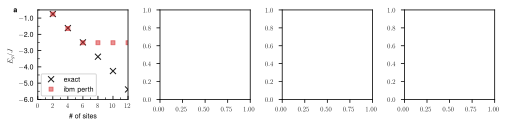

In [96]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size"  : 7
})

cm    = 1.0/2.54
width = 18*cm 
height = 18/4*cm 
plt.figure(figsize=(width,height),dpi=600)

marker_style_ref = dict(marker='',linestyle='dashed',linewidth=1.0, color='black')
marker_style_1  = dict(marker='s', linestyle='none', color='tab:red', alpha=0.5,  fillstyle='full')
marker_style_2  = dict(marker='s', linestyle='none', color='mediumblue', alpha=0.3,  fillstyle='full')
marker_style_3  = dict(marker='x', linestyle='none', color='black', alpha=0.9,  fillstyle='full')


axes = []
ax = plt.subplot2grid((1,4),(0,0))
axes.append(ax)
ax = plt.subplot2grid((1,4),(0,1))
axes.append(ax)
ax = plt.subplot2grid((1,4),(0,2))
axes.append(ax)
ax = plt.subplot2grid((1,4),(0,3))
axes.append(ax)

# (a) compressed, n_trotter=4

axis = axes[0]

y_min    =  -6
y_max    =  -0.5
#
x_min    =  0
x_max    =  12

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
#axes[0].text(-0.25,0.98,'(a)',transform=axes[0].transAxes)
axis.text(-0.27,0.975,r'\textbf{a}',transform=axis.transAxes)
#axes[0].text(0.5,-0.2,r'$R(\AA)$',transform=axes[0].transAxes)
axis.set_xlabel(r'\# of sites')
axis.set_ylabel(r'$E_g/J$')
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(2))
#axis.xaxis.set_major_formatter('{:}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(1))

axis.yaxis.set_major_locator(ticker.MultipleLocator(1))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# plot
ll = [2, 4, 6, 8, 10, 12]
ee = [-0.75]
ee += [eigen_energies_exact[-1,1]]
ee += [-2.493577,-3.37493259,-4.258035,-5.3873]
ee_2 = [-0.75]
ee_2 += [eigen_energies_qzmc[1]]
ee_2 += [-2.493577-0.0205]*4
#axis.plot(ll,ee, label='exact', **marker_style_ref)
axis.plot(ll,ee, label='exact', **marker_style_3)
axis.plot(ll,ee_2, label ='ibm_perth', markersize=4, **marker_style_1)
#ee_renormalized = []
#for i in range(5):
#    ee_renormalized.append(ee[i]/ll[i])
##print(ee_renormalized)
#ee_2_renormalized = []
#for i in range(5):
#    ee_2_renormalized.append(ee_2[i]/ll[i])
#axis.plot(ll,ee_renormalized, label='exact', **marker_style_ref)
#axis.plot(ll,ee_2_renormalized, label ='ibm_perth', markersize=4, **marker_style_1)
#axis.plot(ll,ee_2, label ='ibm_perth', markersize=4, **marker_style_1)

axis.legend(loc='lower left')

# (b) norms

#axis = axes[1]
#
#y_min    = 0.0
#y_max    = 1.05
#
#x_min    =  0
#x_max    =  5.1
#
#axis.set_xlim(x_min,x_max)
#axis.set_ylim(y_min,y_max)
## setup labels
#axis.text(-0.27,0.95,r'\textbf{b}',transform=axis.transAxes)
#axis.set_xlabel(r'$U/t$')
#axis.set_ylabel(r'$\langle{\Psi|\Psi\rangle}$')
##axis.text(0.5,-0.2,r'$U/t$',transform=axis.transAxes)
##axis.text(-0.28,0.5,r'$||\Psi||^2$',transform=axis.transAxes)
## setup tics
#axis.tick_params(axis='x', which='both', direction='in')
#axis.tick_params(axis='y', which='both', direction='in')
#axis.xaxis.set_major_locator(ticker.MultipleLocator(1))
#axis.xaxis.set_major_formatter('{x:0.1f}')
#axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
#
#axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
#axis.yaxis.set_major_formatter('{x:0.1f}')
#axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
#
## plot
#axis.plot(Us_compress[1:],norms_exact_compress[1:], label='exact', **marker_style_ref)
#axis.plot(Us_compress[1:],norms_qasm_compress[1:], label ='noiseless', markersize=4, **marker_style_3)
#axis.plot(Us_compress[1:],norms_perth_compress[1:], label ='ibm_perth', markersize=4, **marker_style_1)
#
#
#axis.legend(loc='lower right')
##
##
## (c) naive, n_trotter=1
#
#axis = axes[2]
#
#y_min    =  -7.1
#y_max    =  -1.9
##
#x_min    =  0
#x_max    =  5.1
#
#axis.set_xlim(x_min,x_max)
#axis.set_ylim(y_min,y_max)
## setup labels
##axes[0].text(-0.25,0.98,'(a)',transform=axes[0].transAxes)
#axis.text(-0.27,0.975,r'\textbf{c}',transform=axis.transAxes)
##axes[0].text(0.5,-0.2,r'$R(\AA)$',transform=axes[0].transAxes)
#axis.set_xlabel(r'$U/t$')
#axis.set_ylabel(r'$E/t$')
## setup tics
#axis.tick_params(axis='x', which='both', direction='in')
#axis.tick_params(axis='y', which='both', direction='in')
#axis.xaxis.set_major_locator(ticker.MultipleLocator(1))
#axis.xaxis.set_major_formatter('{x:0.1f}')
#axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
#
#axis.yaxis.set_major_locator(ticker.MultipleLocator(1))
#axis.yaxis.set_major_formatter('{x:0.1f}')
#axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
#
## plot
#axis.plot(Us_fine,E_fine, label='', **marker_style_ref)
#axis.plot(Us_naive,E_qasm_naive, label ='', markersize=4, **marker_style_3)
##axis.plot(Us_naive,E_perth_naive_woid, label =r'Fig.~8~(a)', markersize=4, **marker_style_2)
##axis.plot(Us_naive,E_perth_naive, label =r'Fig.~8~(d)', markersize=4, **marker_style_1)
#axis.plot(Us_naive,E_perth_naive_woid, label =r'Fig.~S.2~(a)', markersize=4, **marker_style_2)
#axis.plot(Us_naive,E_perth_naive, label =r'Fig.~S.2~(d)', markersize=4, **marker_style_1)
#
#axis.legend(handletextpad=0.4,loc='lower left')
#
## (d) norms
#
#axis = axes[3]
#
#y_min    = 0.0
#y_max    = 1.05
#
#x_min    =  0
#x_max    =  5.1
#
#axis.set_xlim(x_min,x_max)
#axis.set_ylim(y_min,y_max)
## setup labels
#axis.text(-0.27,0.95,r'\textbf{d}',transform=axis.transAxes)
#axis.set_xlabel(r'$U/t$')
#axis.set_ylabel(r'$\langle{\Psi|\Psi\rangle}$')
##axis.text(0.5,-0.2,r'$U/t$',transform=axis.transAxes)
##axis.text(-0.28,0.5,r'$||\Psi||^2$',transform=axis.transAxes)
## setup tics
#axis.tick_params(axis='x', which='both', direction='in')
#axis.tick_params(axis='y', which='both', direction='in')
#axis.xaxis.set_major_locator(ticker.MultipleLocator(1))
#axis.xaxis.set_major_formatter('{x:0.1f}')
#axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
#
#axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
#axis.yaxis.set_major_formatter('{x:0.1f}')
#axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
#
## plot
#axis.plot(Us_naive[0:],norms_exact_naive[0:], label='', **marker_style_ref)
#axis.plot(Us_naive[0:],norms_qasm_naive[0:], label ='', markersize=4, **marker_style_3)
##axis.plot(Us_naive[0:],norms_perth_naive_woid[0:], label =r'Fig.~8~(a)', markersize=4, **marker_style_2)
##axis.plot(Us_naive[0:],norms_perth_naive[0:], label =r'Fig.~8~(d)', markersize=4, **marker_style_1)
#axis.plot(Us_naive[0:],norms_perth_naive_woid[0:], label =r'Fig.~S.2~(a)', markersize=4, **marker_style_2)
#axis.plot(Us_naive[0:],norms_perth_naive[0:], label =r'Fig.~S.2~(d)', markersize=4, **marker_style_1)


#axis.legend(handletextpad=0.4,loc='lower left')
#
#
#
plt.tight_layout()
#

In [67]:
print([eigen_energies_exact[-1,-1]]*5)

[np.float64(-1.6160254037844386), np.float64(-1.6160254037844386), np.float64(-1.6160254037844386), np.float64(-1.6160254037844386), np.float64(-1.6160254037844386)]
